# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [318]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.decomposition import PCA


In [319]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [320]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [321]:
missing = df.isnull().sum()
missing = missing[missing > 0 ].sort_values(ascending=False)

print(missing)

Unnamed: 32    569
dtype: int64


<Axes: xlabel='diagnosis', ylabel='count'>

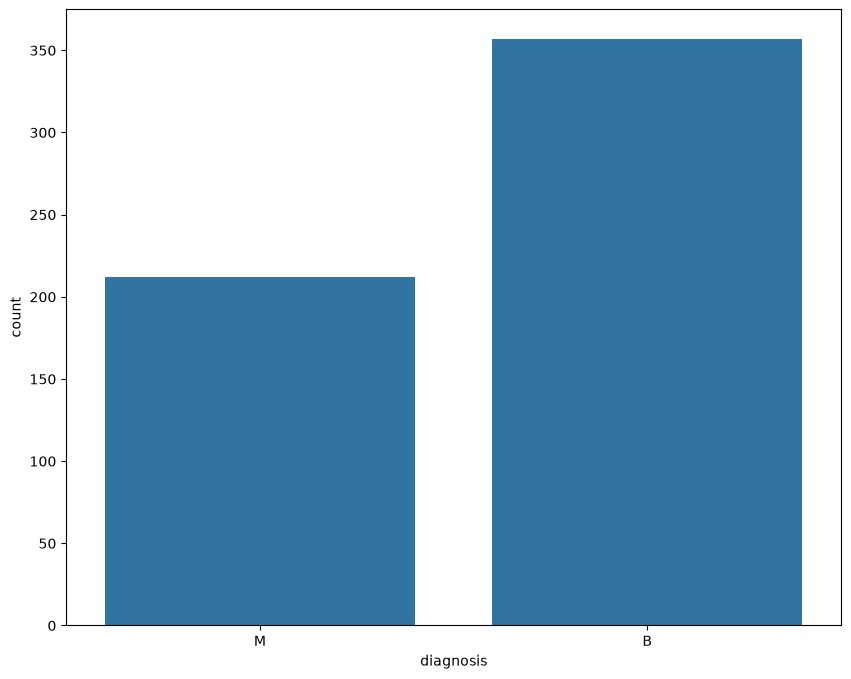

In [322]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    x='diagnosis'
    
)

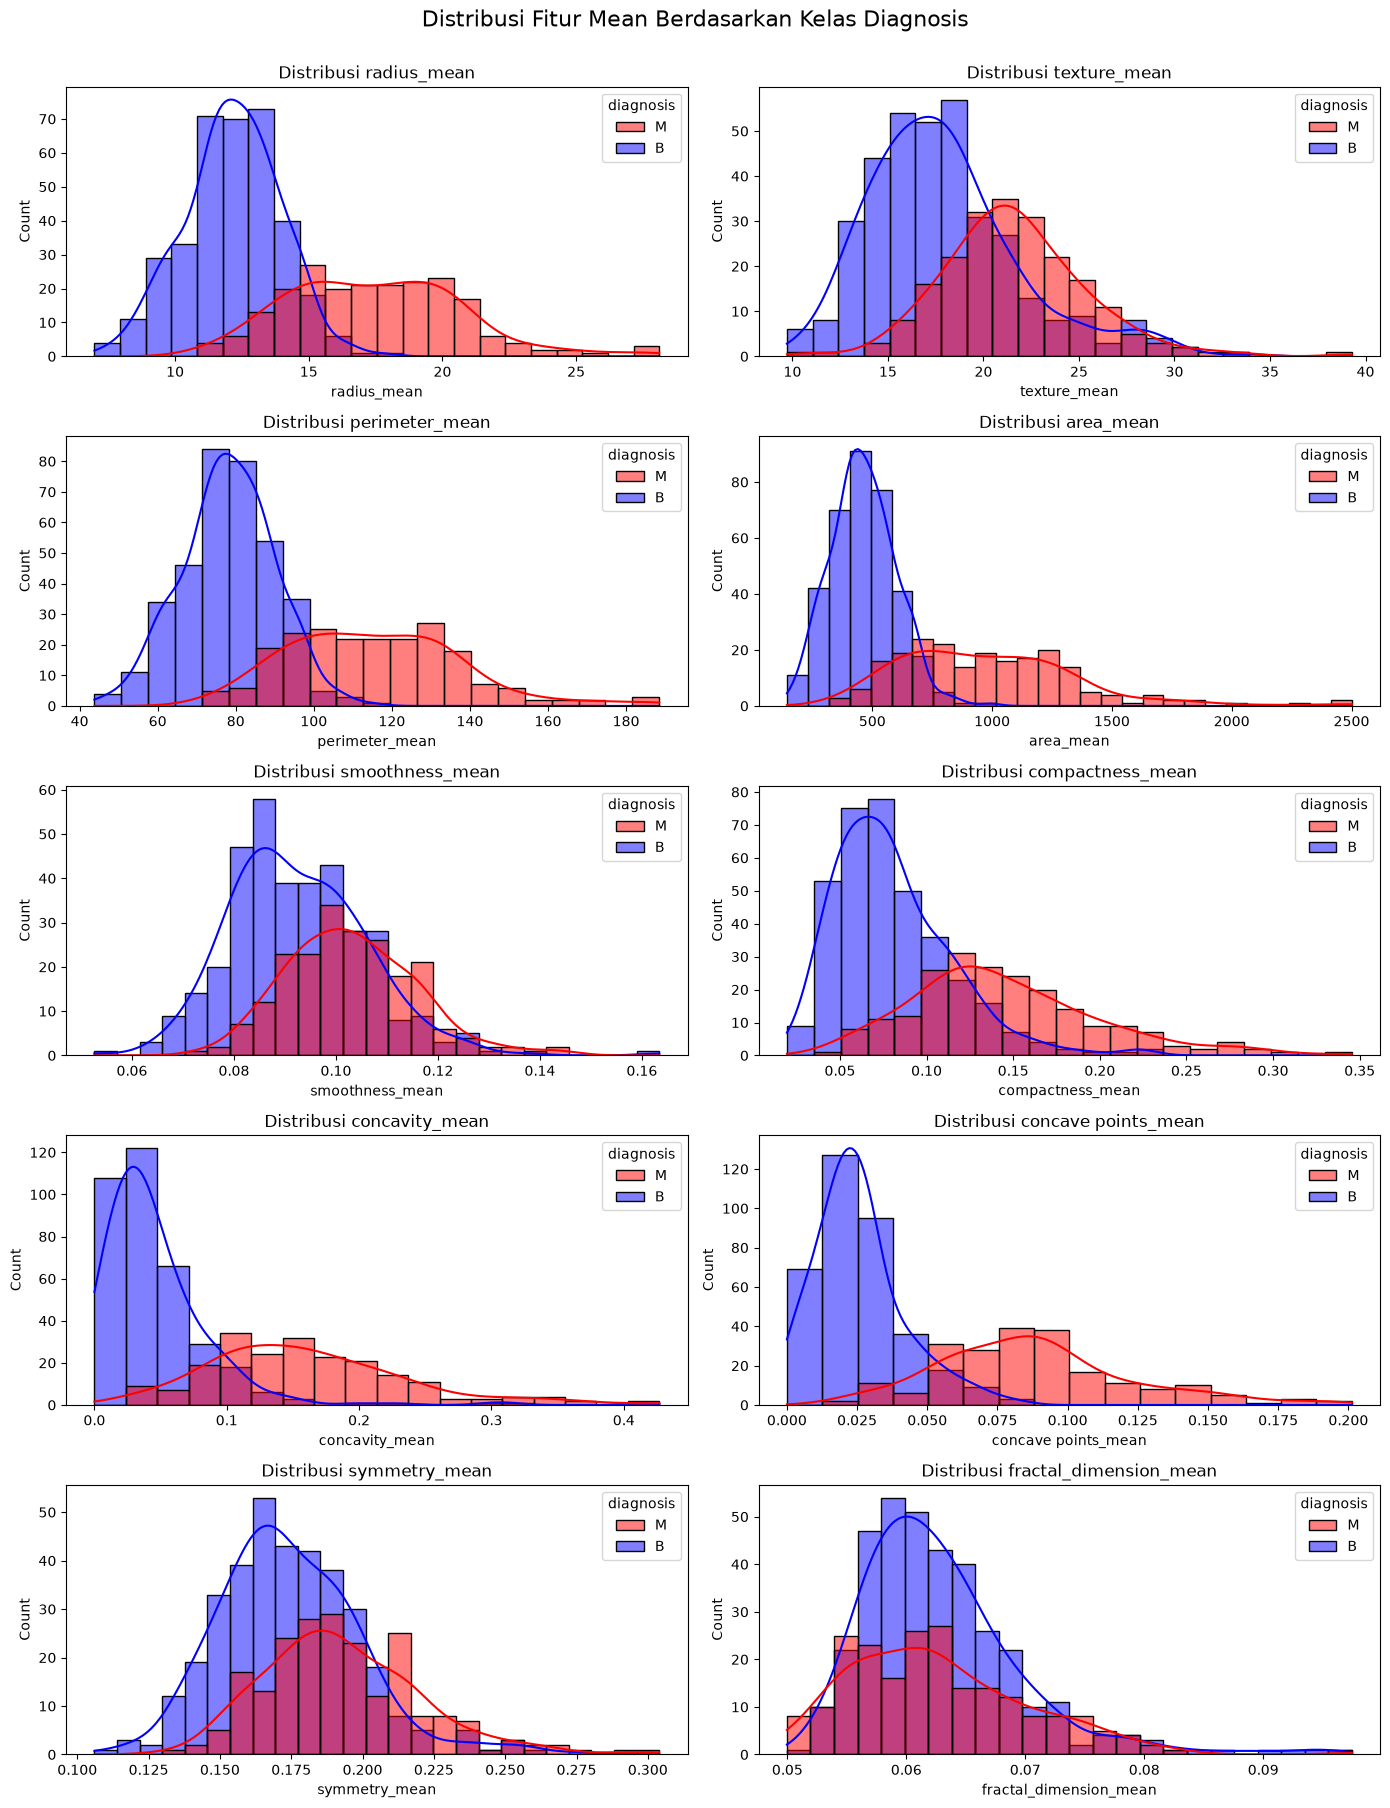

In [323]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.4
# Ambil 10 fitur mean + kolom target 'diagnosis'
mean_features = [col for col in df.columns if col.endswith('_mean')]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=axes[i], palette={'M': 'red', 'B': 'blue'})
    axes[i].set_title(f'Distribusi {col}')

plt.suptitle('Distribusi Fitur Mean Berdasarkan Kelas Diagnosis', fontsize=16, y=1.002)
plt.tight_layout()
plt.show()


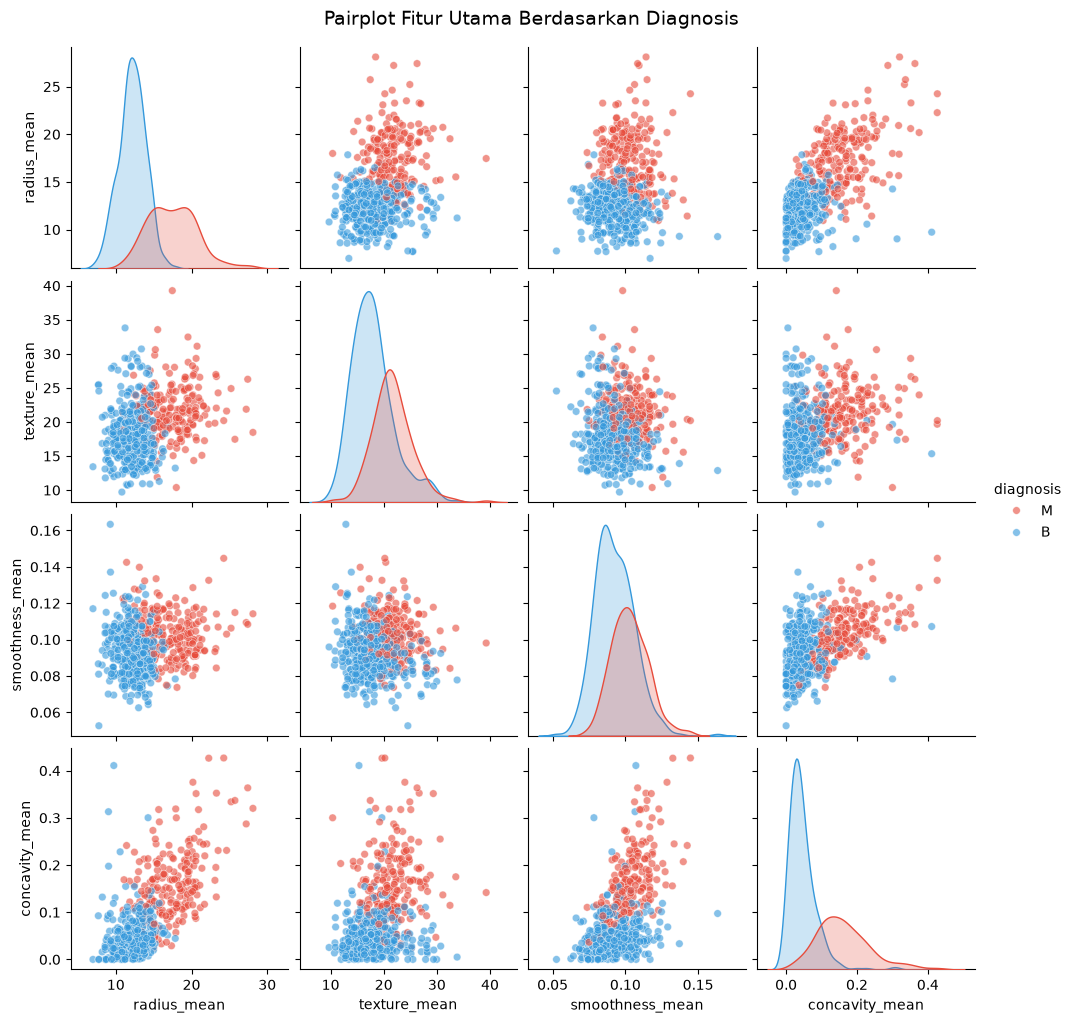

In [324]:
fitur_pilihan = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean', 'diagnosis'
]

sns.pairplot(
    data=df[fitur_pilihan],
    hue='diagnosis',
    palette={'M': '#e74c3c', 'B': '#3498db'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)

plt.suptitle('Pairplot Fitur Utama Berdasarkan Diagnosis', y=1.02, fontsize=14)
plt.show()


C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_15336\796061456.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i], palette={'M': '#e74c3c', 'B': '#3498db'})
C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_15336\796061456.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i], palette={'M': '#e74c3c', 'B': '#3498db'})
C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_15336\796061456.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, a

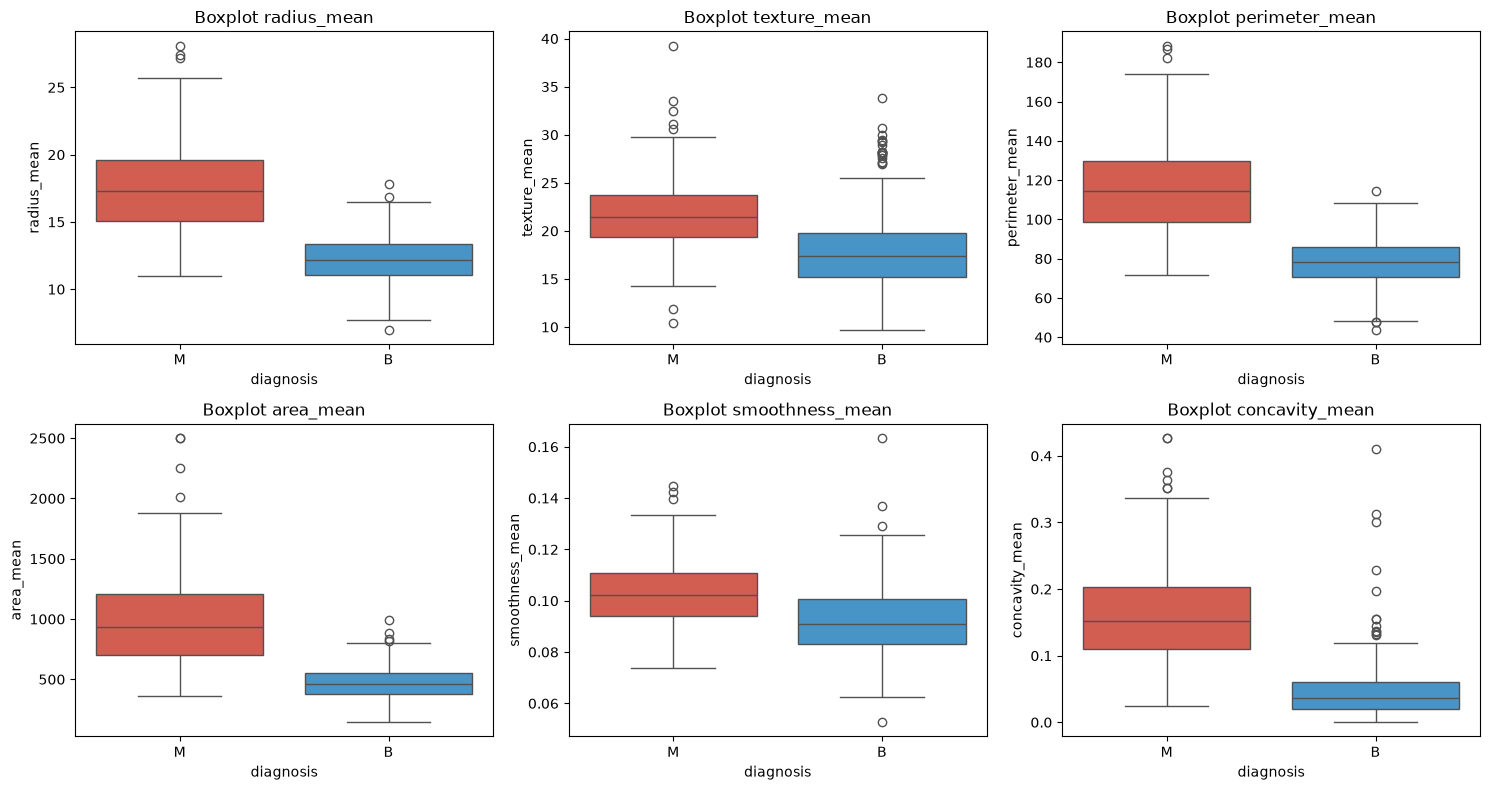

In [325]:
fitur_pilihan = ['radius_mean', 'texture_mean', 'perimeter_mean', 
                 'area_mean', 'smoothness_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_pilihan):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i], palette={'M': '#e74c3c', 'B': '#3498db'})
    axes[i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()


In [326]:
fitur_numerik = df.drop(columns=['id', 'Unnamed: 32', 'diagnosis'], errors='ignore')

outlier_summary = []
for col in fitur_numerik.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (n_outliers / len(df)) * 100
    
    if n_outliers > 0:
        outlier_summary.append({'Fitur': col, 'Jumlah Outlier': n_outliers, 'Persentase (%)': round(pct_outliers, 2)})

# Tampilkan dalam bentuk DataFrame rapi
df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Jumlah Outlier', ascending=False)
print("=== DAFTAR OUTLIER DI SEMUA FITUR ===")
df_outliers


=== DAFTAR OUTLIER DI SEMUA FITUR ===


,Fitur,Jumlah Outlier,Persentase (%)
13,area_se,65,11.42
10,radius_se,38,6.68
12,perimeter_se,38,6.68
23,area_worst,35,6.15
14,smoothness_se,30,5.27
15,compactness_se,28,4.92
19,fractal_dimension_se,28,4.92
18,symmetry_se,27,4.75
3,area_mean,25,4.39
28,fractal_dimension_worst,24,4.22


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [327]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = df.drop(columns=['id', 'Unnamed: 32'])

In [328]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [329]:
# Pisahkan fitur (X) dan target (y).
from numpy import column_stack
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [330]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [331]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(
    kernel='linear', 
    C=1.0
)
    
svm_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [332]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Train:", accuracy_score(y_train, svm_linear.predict(X_train_scaled)))
print("Test :", accuracy_score(y_test, y_pred_linear))
print("n_support_:", svm_linear.n_support_)

Train: 0.989010989010989
Test : 0.9649122807017544
n_support_: [19 19]


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [333]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_RBF = SVC(
    kernel='rbf', 
    C=1.0
)

svm_RBF.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [334]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_RBF = svm_RBF.predict(X_test_scaled)

print("Train:", accuracy_score(y_train, svm_RBF.predict(X_train_scaled)))
print("Test :", accuracy_score(y_test, y_pred_RBF))
print("n_support_:", svm_RBF.n_support_)

Train: 0.9868131868131869
Test : 0.9736842105263158
n_support_: [50 57]


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [335]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []

In [336]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
for C in C_values:
    model = SVC(kernel='rbf', C=C, gamma='scale')
    model.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_scaled)))

for C in C_values:
    m = SVC(kernel='rbf', C=C, gamma='scale').fit(X_train_scaled, y_train)
    print(f"C={C} acc_test={accuracy_score(y_test, m.predict(X_test_scaled)):.4f} f1_test={f1_score(y_test, m.predict(X_test_scaled)):.4f}")

C=0.01 acc_test=0.6316 f1_test=0.0000
C=0.1 acc_test=0.9474 f1_test=0.9231
C=1 acc_test=0.9737 f1_test=0.9630
C=10 acc_test=0.9737 f1_test=0.9630
C=100 acc_test=0.9649 f1_test=0.9524


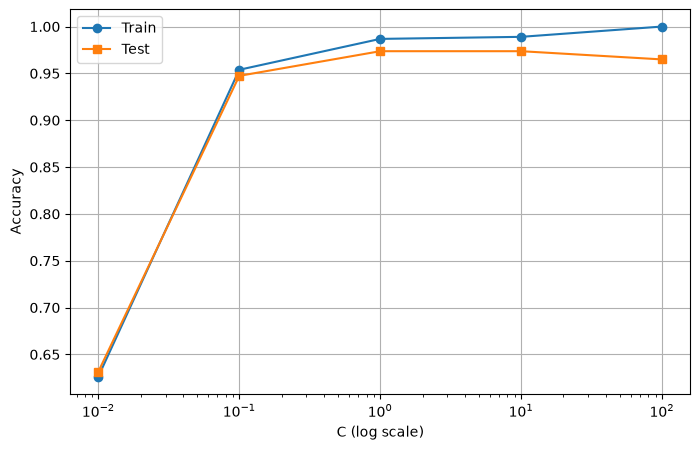

In [337]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8,5))
plt.semilogx(C_values, train_acc, marker='o', label='Train')
plt.semilogx(C_values, test_acc, marker='s', label='Test')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [338]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def skor(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

df_eval = pd.DataFrame(
    [skor(y_test, y_pred_linear), skor(y_test, y_pred_RBF)],
    index=['Linear (C=1)', 'RBF (C=1)'],
    columns=['Accuracy','Precision','Recall','F1']
)
df_eval

,Accuracy,Precision,Recall,F1
Linear (C=1),0.964912,1.0,0.904762,0.950000
RBF (C=1),0.973684,1.0,0.928571,0.962963


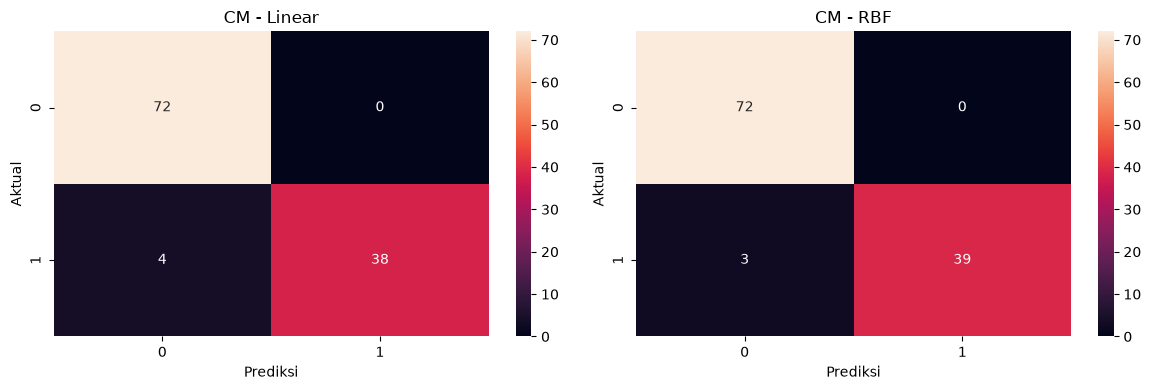

In [339]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, y_pred, title in zip(axes, [y_pred_linear, y_pred_RBF], ['Linear','RBF']):
    sns.heatmap(confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    ax=ax
)
    ax.set_title(f'CM - {title}'); ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [340]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print("Linear:", svm_linear.n_support_, "total:", svm_linear.n_support_.sum())
print("RBF   :", svm_RBF.n_support_, "total:", svm_RBF.n_support_.sum())

Linear: [19 19] total: 38
RBF   : [50 57] total: 107


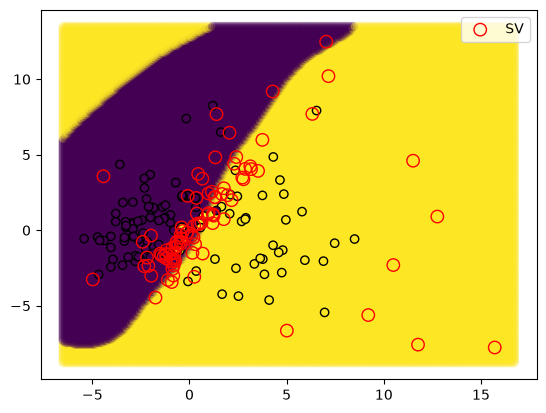

In [341]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2)
Xtr_2d = pca.fit_transform(X_train_scaled)
Xte_2d = pca.transform(X_test_scaled)

best = SVC(kernel='rbf', C=1.0, gamma='scale').fit(Xtr_2d, y_train)

xx, yy = np.meshgrid(
    np.linspace(Xtr_2d[:,0].min()-1, Xtr_2d[:,0].max()+1, 200),
    np.linspace(Xtr_2d[:,1].min()-1, Xtr_2d[:,1].max()+1, 200))
Z = best.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.scatter(xx, yy, c=Z, alpha=0.2)
plt.scatter(Xte_2d[:,0], Xte_2d[:,1], c=y_test, edgecolors='k')
plt.scatter(best.support_vectors_[:,0], best.support_vectors_[:,1], facecolors='none', edgecolors='r', s=80, label='SV')
plt.legend(); plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Kernel Linear vs RBF:

Hasil: RBF unggul tipis dengan Akurasi 97.37% (F1: 96.30%) dibanding Linear dengan Akurasi 96.49% (F1: 95.00%).
Kaitan dengan EDA: Kedua model berkinerja tinggi (>96%) karena sebagian besar data M dan B pada pairplot sudah terpisah secara alami (linearly separable). Namun, RBF lebih unggul karena mampu membentuk batas melengkung pada area perbatasan yang tumpang tindih (overlap), sehingga berhasil menekan angka False Negative dari 4 menjadi 3 pasien.

Eksperimen Regularisasi ($C$):
$C = 0.01$ (Underfitting): Akurasi hanya 63.16% (F1: 0.00%) karena margin terlalu longgar dan model memprediksi semua data sebagai kelas mayoritas (B).
$C = 1.0$ (Optimal): Titik terbaik (sweet spot) dengan akurasi uji puncak 97.37%.
$C = 100$ (Mulai Overfitting): Akurasi train naik mendekati 100%, tetapi akurasi test turun menjadi 96.49%. Margin yang terlalu sempit membuat model menghafal noise data train sehingga kemampuan generalisasinya menurun.

Jumlah Support Vectors & Kompleksitas:
Linear (38 SV): Hanya butuh sedikit support vector karena bidang pemisahnya datar dan sederhana.
RBF (107 SV): Membutuhkan support vector hampir 3x lipat lebih banyak untuk membentuk dan menopang kontur batas keputusan non-linear yang kompleks.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Model Terbaik: SVM Kernel RBF ($C=1.0$) adalah model terbaik dengan Akurasi 97.37%, Precision 100%, dan Recall 92.86%, serta paling aman untuk diagnosis medis karena meminimalkan pasien kanker yang salah terdeteksi (False Negative).
Pentingnya Scaling: Standardisasi fitur (StandardScaler) sangat krusial karena SVM berbasis jarak dan skala nilai antar fitur sangat timpang.

Pengaruh $C$: Parameter $C$ mengontrol trade-off margin; nilai terlalu kecil memicu underfitting, sedangkan nilai terlalu besar memicu overfitting.
Saran

GridSearchCV: Melakukan tuning kombinasi nilai $C$ dan $\gamma$ secara simultan untuk menemukan kelengkungan boundary RBF yang paling optimal.

Seleksi Fitur (Feature Selection): Mengurangi fitur yang redundan/multikolinear (seperti radius, perimeter, dan area yang saling berkorelasi tinggi) untuk mempercepat komputasi.

Optimasi Threshold / Class Weight: Menerapkan penyesuaian threshold probabilitas atau bobot kelas (class_weight='balanced') agar nilai Recall dapat mencapai 100%.